# Gravity-wave analysis (h-NUMO `gravity_wave` test case)

Internal gravity-wave propagation test based on Chen (2025). Two layers, flow initially at rest with a cosine-bell hump
on the interface, non-rotating. Excites a fast barotropic and a slower
baroclinic gravity wave.

This notebook bins the layer-2 thickness deviation by great-circle distance
from the hump center at two snapshot times, estimates the barotropic
wavefront speed from the shift in the leading edge, and renders lon-lat maps.

In [1]:
import sys, os, re
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))
from numo_vtk import (read_vtk_ascii, great_circle_km, radial_bin_mean, plot_latlon_map,
                       snapshot_time_hours, CIRCUMFERENCE_KM)

%matplotlib inline

In [2]:
# ---------------- SETTINGS ----------------
# Barotropic mode (~140 m/s): needs a SHORT snapshot pair, well inside one
# circumnavigation time (circumference / speed ~ 79h) -- past that the front
# wraps around and converges/focuses at the antipode, and the simple
# "leading edge from source" tracking below becomes meaningless. This run
# only saved sparse late snapshots (100, 200, 224h), so even the earliest
# available pair is already ~1.3 circumnavigations in -- the warning below
# will (correctly) flag this. Point RUNDIR_BTP/FPREFIX_BTP at a different,
# earlier-snapshot run once you have one, for a real barotropic measurement.
RUNDIR_BTP = '/Users/yao/Documents/Code/Gravity_Sphere/'
FPREFIX_BTP = 'mlswe_sphere_600.0000_dg_rk35_l002_'
TIME_RESTART_HOURS_BTP = 1.0
IDX1_BTP, IDX2_BTP = 8, 16

# Baroclinic mode (~10-14 m/s): needs a LONG snapshot pair (Chen's paper used
# ~150-225h) for the front to separate from the initial hump's own footprint
# (radius ~1112km). This is the pair that gave the good 9.7 m/s result.
RUNDIR_BCL = '/Users/yao/Documents/Code/Gravity_Sphere/'
FPREFIX_BCL = 'mlswe_sphere_600.0000_dg_rk35_l002_'
TIME_RESTART_HOURS_BCL = 1.0
IDX1_BCL, IDX2_BCL = 50, 224

BACKGROUND = 1000.0      # resting layer thickness (m)
LON0, LAT0 = 0.0, 0.0    # hump center (radians)
BINWIDTH_KM = 500.0
BTP_THRESHOLD = 0.01    # m; deviation magnitude marking the leading edge of
                        # the fast (barotropic) wave, well above the ~0.001-
                        # 0.002m interpolation noise floor but well below
                        # real signal (tens of m near source, ~0.05m at the
                        # barotropic front itself)
BCL_THRESHOLD = 2.0     # m; deviation magnitude marking the edge of the
                        # baroclinic disturbance -- much larger than
                        # BTP_THRESHOLD since the baroclinic signal itself is
                        # O(10s of m).
RHO1, RHO2 = 1000.0, 1020.0  # layer densities (kg/m^3), from
                              # initial_conditions_sphere.F90's 'gravity_wave'
                              # case (paper's other tested config: 1040)
GRAVITY = 9.81
PHI1, PHI2 = 1000.0, 1000.0   # background layer thicknesses (m)
PREDICTED_BTP_SPEED = np.sqrt(GRAVITY * (PHI1 + PHI2))
G_REDUCED = GRAVITY * (RHO2 - RHO1) / RHO1
PREDICTED_BCL_SPEED = np.sqrt(G_REDUCED * PHI1 * PHI2 / (PHI1 + PHI2))

def _dt_seconds(fprefix):
    # dt (bcl time step) is embedded literally in h-NUMO's filename, e.g.
    # "..._600.0000_...". Needed because the *actual* spacing between VTK
    # snapshots is irestart*dt (irestart = NINT(time_restart_seconds/dt)),
    # which only equals the nominal time_restart when dt evenly divides
    # 1800s -- see numo_vtk.snapshot_time_hours.
    return float(re.search(r'_(\d+\.\d+)_', fprefix).group(1))

def load(rundir, fprefix, idx, time_restart_hours):
    dt_seconds = _dt_seconds(fprefix)
    t = snapshot_time_hours(idx, dt_seconds, time_restart_hours)
    f = os.path.join(rundir, f'{fprefix}{idx:04d}.vtk')
    d = read_vtk_ascii(f, fields=['h'])
    print(f"Loaded {len(d['h'])} points from {f} at t={t:.1f}h")
    return t, d

def radial_profile(d):
    dist = great_circle_km(LON0, LAT0, d['lon'], d['lat'])
    dev = d['h'] - BACKGROUND
    return radial_bin_mean(dist, dev, BINWIDTH_KM)

def check_circumnavigation(label, t_hours, predicted_speed_ms):
    expected_r_km = predicted_speed_ms * t_hours * 3600.0 / 1000.0
    half_circumference = CIRCUMFERENCE_KM / 2.0
    if expected_r_km > half_circumference:
        n_wraps = expected_r_km / CIRCUMFERENCE_KM
        print(f"*** WARNING: at t={t_hours:.1f}h the {label} wave (predicted "
              f"{predicted_speed_ms:.1f} m/s) would already have travelled "
              f"~{expected_r_km:.0f} km, past the antipode ({half_circumference:.0f} km) "
              f"-- roughly {n_wraps:.2f} circumnavigations. The leading-edge "
              f"measurement below is likely contaminated by wraparound/antipodal "
              f"focusing; use a shorter snapshot pair (from an earlier-snapshot run "
              f"if this run only saved sparse late-time output). ***")
# -------------------------------------------

In [3]:
check_circumnavigation("barotropic",
                        snapshot_time_hours(IDX2_BTP, _dt_seconds(FPREFIX_BTP), TIME_RESTART_HOURS_BTP),
                        PREDICTED_BTP_SPEED)

t1_btp, d1_btp = load(RUNDIR_BTP, FPREFIX_BTP, IDX1_BTP, TIME_RESTART_HOURS_BTP)
t2_btp, d2_btp = load(RUNDIR_BTP, FPREFIX_BTP, IDX2_BTP, TIME_RESTART_HOURS_BTP)
centers_btp, mean1_btp = radial_profile(d1_btp)
_, mean2_btp = radial_profile(d2_btp)

same_pair = ((RUNDIR_BCL, FPREFIX_BCL, IDX1_BCL, IDX2_BCL, TIME_RESTART_HOURS_BCL) ==
             (RUNDIR_BTP, FPREFIX_BTP, IDX1_BTP, IDX2_BTP, TIME_RESTART_HOURS_BTP))
if same_pair:
    t1_bcl, t2_bcl = t1_btp, t2_btp
    centers_bcl, mean1_bcl, mean2_bcl = centers_btp, mean1_btp, mean2_btp
    d1_bcl, d2_bcl = d1_btp, d2_btp
else:
    t1_bcl, d1_bcl = load(RUNDIR_BCL, FPREFIX_BCL, IDX1_BCL, TIME_RESTART_HOURS_BCL)
    t2_bcl, d2_bcl = load(RUNDIR_BCL, FPREFIX_BCL, IDX2_BCL, TIME_RESTART_HOURS_BCL)
    centers_bcl, mean1_bcl = radial_profile(d1_bcl)
    _, mean2_bcl = radial_profile(d2_bcl)

Loaded 150000 points from /Users/yao/Documents/Code/Gravity_Sphere/mlswe_sphere_600.0000_dg_rk35_l002_0008.vtk at t=8.0h
Loaded 150000 points from /Users/yao/Documents/Code/Gravity_Sphere/mlswe_sphere_600.0000_dg_rk35_l002_0016.vtk at t=16.0h
Loaded 150000 points from /Users/yao/Documents/Code/Gravity_Sphere/mlswe_sphere_600.0000_dg_rk35_l002_0050.vtk at t=50.0h
Loaded 150000 points from /Users/yao/Documents/Code/Gravity_Sphere/mlswe_sphere_600.0000_dg_rk35_l002_0224.vtk at t=224.0h


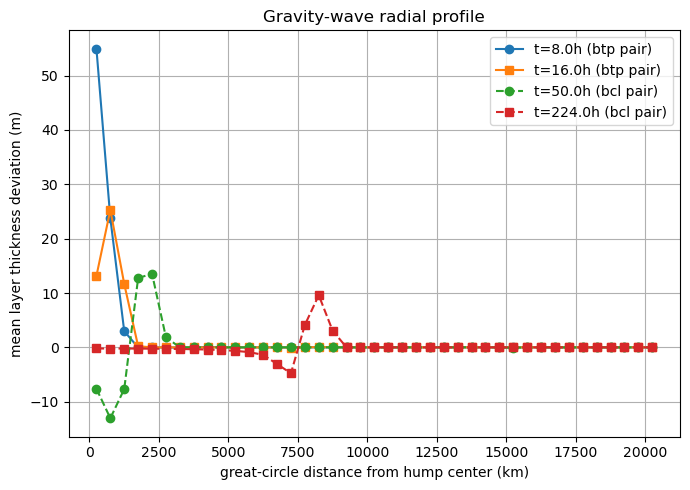

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(centers_btp, mean1_btp, '-o', label=f't={t1_btp:.1f}h (btp pair)')
ax.plot(centers_btp, mean2_btp, '-s', label=f't={t2_btp:.1f}h (btp pair)')
if not same_pair:
    ax.plot(centers_bcl, mean1_bcl, '--o', label=f't={t1_bcl:.1f}h (bcl pair)')
    ax.plot(centers_bcl, mean2_bcl, '--s', label=f't={t2_bcl:.1f}h (bcl pair)')
ax.set_xlabel('great-circle distance from hump center (km)')
ax.set_ylabel('mean layer thickness deviation (m)')
ax.set_title('Gravity-wave radial profile')
ax.legend(); ax.grid(True)
fig.tight_layout()

In [5]:
def leading_edge(centers, mean, threshold):
    """Outermost radius where |mean| still exceeds `threshold`, i.e. the
    leading edge of whichever mode that threshold is tuned for -- NOT
    wherever |mean| happens to be locally largest (that can instead pick
    out a different mode's larger-amplitude residual nearer the source)."""
    absmean = np.nan_to_num(np.abs(mean))
    above = np.where(absmean > threshold)[0]
    if len(above) == 0:
        return np.nan
    i = above[-1]
    # Linear-interpolate the threshold crossing between bin i (above
    # threshold) and bin i+1 (below) for sub-bin precision.
    if i == len(centers) - 1 or np.isnan(mean[i + 1]):
        return centers[i]
    y0, y1 = absmean[i], absmean[i + 1]
    if y0 == y1:
        return centers[i]
    frac = (y0 - threshold) / (y0 - y1)
    return centers[i] + frac * (centers[i + 1] - centers[i])

r1_btp = leading_edge(centers_btp, mean1_btp, BTP_THRESHOLD)
r2_btp = leading_edge(centers_btp, mean2_btp, BTP_THRESHOLD)
speed_btp = (r2_btp - r1_btp) * 1000.0 / ((t2_btp - t1_btp) * 3600.0)

r1_bcl = leading_edge(centers_bcl, mean1_bcl, BCL_THRESHOLD)
r2_bcl = leading_edge(centers_bcl, mean2_bcl, BCL_THRESHOLD)
speed_bcl = (r2_bcl - r1_bcl) * 1000.0 / ((t2_bcl - t1_bcl) * 3600.0)

print(f"Barotropic front: t={t1_btp:.1f}h -> r={r1_btp:.0f} km,  t={t2_btp:.1f}h -> r={r2_btp:.0f} km")
print(f"Estimated barotropic speed: {speed_btp:.1f} m/s  (predicted ~{PREDICTED_BTP_SPEED:.1f} m/s)")

print(f"\nBaroclinic front: t={t1_bcl:.1f}h -> r={r1_bcl:.0f} km,  t={t2_bcl:.1f}h -> r={r2_bcl:.0f} km")
print(f"Estimated baroclinic speed: {speed_bcl:.1f} m/s  (predicted ~{PREDICTED_BCL_SPEED:.1f} m/s)")
if same_pair:
    print("(Baroclinic estimate reuses the barotropic pair's short snapshot times -- unreliable; "
          "set IDX1_BCL/IDX2_BCL (and RUNDIR_BCL/FPREFIX_BCL if it's a different run) to a long "
          "run's indices, e.g. ~150-225h apart, for a clean measurement.)")

Barotropic front: t=8.0h -> r=5076 km,  t=16.0h -> r=9059 km
Estimated barotropic speed: 138.3 m/s  (predicted ~140.1 m/s)

Baroclinic front: t=50.0h -> r=2744 km,  t=224.0h -> r=8924 km
Estimated baroclinic speed: 9.9 m/s  (predicted ~9.9 m/s)


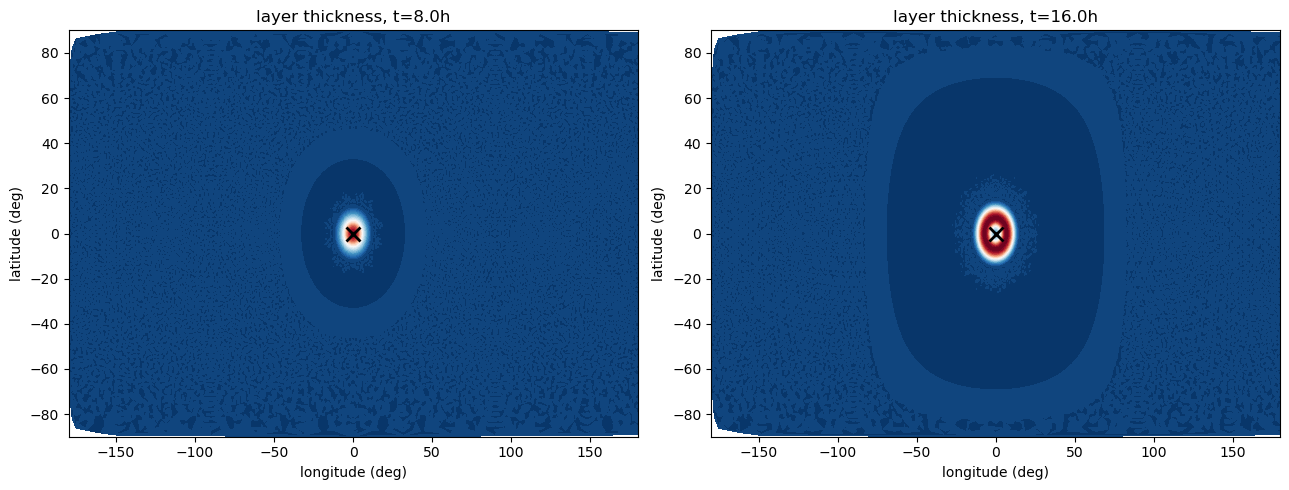

In [6]:
fig2, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_latlon_map(axes[0], d1_btp['lon'], d1_btp['lat'], d1_btp['h'],
                 title=f'layer thickness, t={t1_btp:.1f}h',
                 mark_point=(np.degrees(LON0), np.degrees(LAT0)))
plot_latlon_map(axes[1], d2_btp['lon'], d2_btp['lat'], d2_btp['h'],
                 title=f'layer thickness, t={t2_btp:.1f}h',
                 mark_point=(np.degrees(LON0), np.degrees(LAT0)))
fig2.tight_layout()